# Data Visualizations

In [1]:
# import packages 
import numpy as np
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

In [2]:
# colors 

'#f5f0e8'   # body-bg, hero bg, conclusion text, back-btn hover area
'#1a1a1a'   # body-color, hero h1, narrative-block text, conclusion bg, picker-btn active border
'#320b8d'   # link-color, kicker, artist-a accent, border-left on narrative-block, back-btn text
'#06395b'   # artist-b accent
'#4f0335'   # artist-c accent
'#252525'   # conclusion type-card background

'#252525'

In [3]:
# theme 
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "none",
        "axes.facecolor": "none",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 20
    }
)

font_manager.fontManager.addfont("PlayfairDisplay-VariableFont_wght.ttf")
plt.rcParams["font.family"] = "Playfair Display"

In [4]:
# load data 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)

## Number of Songs per Artist

In [5]:
# get unique songs
df_artist = df.copy()
df_artist = df_artist.groupby(by=['title','artist','artist_list']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()

# explode artist list to make one obs per artist 
df_artist['artist_list'] = df_artist['artist_list'].apply(ast.literal_eval)
df_artist = df_artist.explode('artist_list')

# count number of songs 
num_songs_per_artist = df_artist.groupby(by=['artist_list']).agg(num_songs = ('title','count')).reset_index()
num_songs_per_artist = num_songs_per_artist.sort_values('num_songs', ascending=False)

In [28]:
num_songs_per_artist.head(20)

,artist_list,num_songs
380,Drake,266
1264,Taylor Swift,211
484,Future,196
788,Lil Baby,157
1337,Travis Scott,127
116,Bad Bunny,113
802,Lil Uzi Vert,113
5,21 Savage,111
936,Morgan Wallen,106
1430,YoungBoy Never Broke Again,104


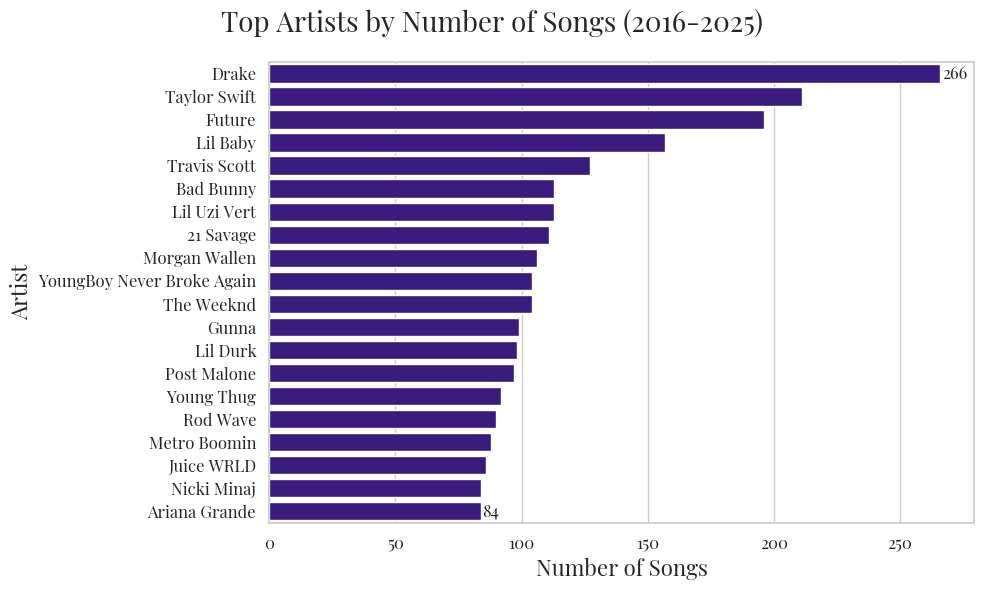

In [6]:
# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d')

max_idx = 0
min_idx = 19

for i, row in artist_counts.iterrows():
    if i == max_idx or i == min_idx:
        ax.text(
            row['num_songs'] + 0.5,
            artist_counts.index.get_loc(i),
            str(row['num_songs']),
            va='center'
        )

plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.suptitle("Top Artists by Number of Songs (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_songs_per_artist.svg', format='svg')

plt.show()

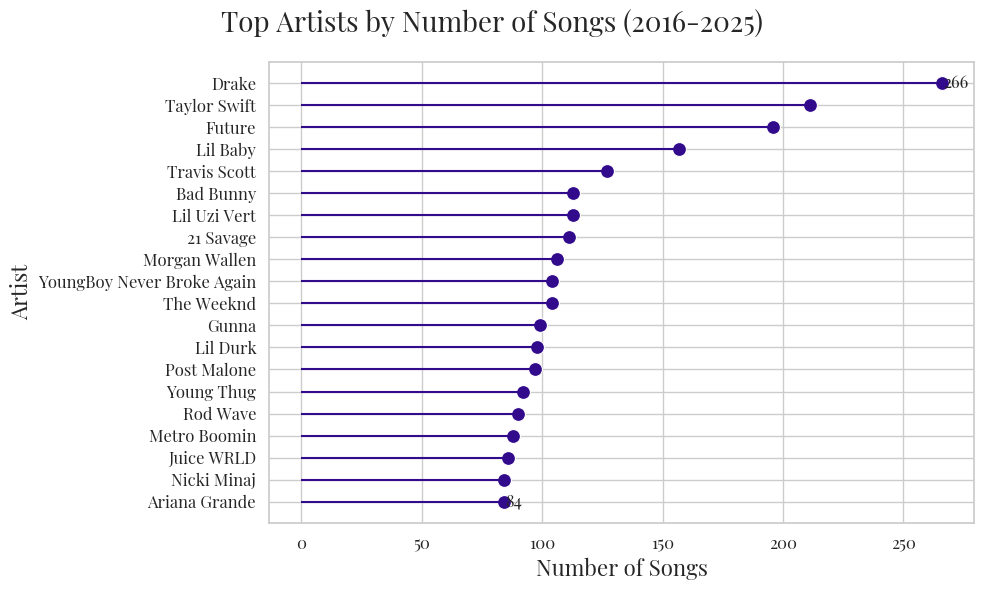

In [79]:
# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
# sns.barplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d')


ax.hlines(y=artist_counts['artist_list'],
          xmin=0,
          xmax=artist_counts['num_songs'],
          color='#320b8d')

sns.scatterplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d',
                s=100,
                ax=ax)

max_idx = 0
min_idx = 19

for i, row in artist_counts.iterrows():
    if i == max_idx or i == min_idx:
        ax.text(
            row['num_songs'] + 0.5,
            artist_counts.index.get_loc(i),
            str(row['num_songs']),
            va='center'
        )

plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.suptitle("Top Artists by Number of Songs (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
# plt.savefig('../charts/num_songs_per_artist.svg', format='svg')

plt.show()

## Max Number of Weeks on Chart per Song

In [7]:
# get unique songs
df_songs = df.copy()
df_songs = df_songs.groupby(by=['title','artist']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()
num_weeks_per_song = df_songs.sort_values(by=['weeks_in_data'], ascending=False)

In [62]:
num_weeks_per_song.head(20)

,title,artist,weeks_in_data,max_weeks_on_chart
2984,Lose Control,Teddy Swims,112,112
2134,Heat Waves,Glass Animals,91,91
621,Blinding Lights,The Weeknd,90,90
487,Beautiful Things,Benson Boone,89,89
123,A Bar Song (Tipsy),Shaboozey,77,77
2869,Levitating,Dua Lipa,77,77
5649,Wildflower,Billie Eilish,72,72
4561,Snooze,SZA,70,70
4337,Save Your Tears,The Weeknd & Ariana Grande,69,69
3924,Pink Pony Club,Chappell Roan,68,68


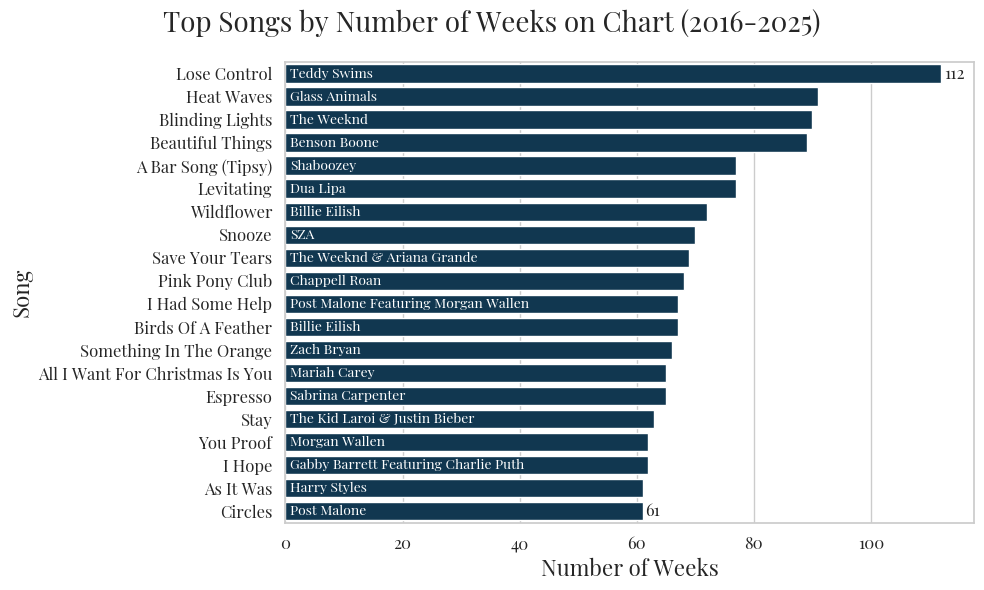

In [8]:
# keep top N songs
top_n = 20
song_counts = num_weeks_per_song.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=song_counts, x='weeks_in_data', y='title', color='#06395b')

max_idx = 0
min_idx = 19

for i, row in song_counts.iterrows():
    ax.text(
        0.75,
        song_counts.index.get_loc(i),
        str(row['artist']),
        va='center',
        color='white',
        size=10
    )
    if i == max_idx or i == min_idx:
        ax.text(
            row['weeks_in_data'] + 0.5,
            song_counts.index.get_loc(i),
            str(row['weeks_in_data']),
            va='center'
        )

plt.xlabel('Number of Weeks')
plt.ylabel('Song')
plt.suptitle("Top Songs by Number of Weeks on Chart (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_weeks_per_song.svg', format='svg')

plt.show()

## Linked View 

In [57]:
# fill in middle off chart weeks for each song 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)
songs = df[['title', 'artist']].drop_duplicates()

In [55]:
def fill_song(group):

    group = group.sort_values("chart_date")

    full_range = pd.date_range(
        start=group["chart_date"].min(),
        end=group["chart_date"].max(),
        freq="W-SAT"
    )
    new_rows = pd.DataFrame(data = {
        'chart_date': full_range,
        'title': group["title"].iloc[0],
        'artist': group["artist"].iloc[0]
    })
    if new_rows.shape[0] != group.shape[0]:
        new_group = new_rows.merge(group, how='left')
        return new_group 
    else:
        return group

df["chart_date"] = pd.to_datetime(df["chart_date"])
dfs = []
for row in songs.iterrows():
    mask = (df['title']==str(row[1]['title']))&(df['artist']==str(row[1]['artist']))
    group = df.loc[mask]
    song = fill_song(group)
    dfs.append(song)
df_filled = pd.concat(dfs)

In [56]:
df_filled.to_csv('../data/filled_hot100_history.csv', index=False)

## Flash vs Burn categorization

In [60]:
# import data 
df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)

# get rid of songs that only appear for one week 
counts = df.groupby(["title", "artist"])["chart_date"].transform("size")
df = df[counts > 1]

# for simplicity, get rid of songs that fall off the chart 
mask = df.groupby(["title", "artist"])["rank"].transform(lambda x: x.notna().all())
df = df[mask]

In [138]:
# viral df 

# get new per song columns  
songs = []
for (artist, title, artist_list), group in df.groupby(['artist', 'title', 'artist_list']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = len(g.notna())

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        peak_week = g['rank'].idxmin() 

        # pre peak data  
        pre_peak = g.iloc[:peak_week+1]

        if len(pre_peak) < 2:
                # dont include songs that start at their peak 
                continue
        else:
                # average rank change per week before peak
                rank_changes = pre_peak['rank'].diff().dropna()
                rise_rate = -rank_changes.mean()

                songs.append({
                        'artist': artist,
                        'title': title,
                        'artist_list': artist_list,
                        'total_weeks': total_weeks,
                        'peak_rank': peak_rank,
                        'debut_rank': debut_rank,
                        'peak_week': peak_week,
                        'rise_rate': rise_rate
                })

viral_df = pd.DataFrame(songs)

In [131]:
viral_df.head()

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,peak_week,rise_rate
0,2 Chainz,Watch Out,['2 Chainz'],11,64.0,85.0,4,5.250000
1,2 Chainz Featuring Travis Scott,4 AM,"['2 Chainz', 'Travis Scott']",12,55.0,73.0,2,9.000000
2,"2 Chainz Featuring Ty Dolla $ign, Trey Songz &...",It's A Vibe,"['2 Chainz', 'Ty Dolla $ign', 'Trey Songz', 'J...",20,44.0,95.0,10,5.100000
3,21 Savage,A Lot,['21 Savage'],23,12.0,37.0,6,4.166667
4,21 Savage,Bank Account,['21 Savage'],28,12.0,33.0,4,5.250000


In [113]:
viral_df['rise_rate'].describe()

count    1271.000000
mean        7.234650
std         9.593411
min         0.047619
25%         2.571429
50%         4.454545
75%         7.651515
max        98.000000
Name: rise_rate, dtype: float64

In [114]:
import plotly.express as px 

fig = px.scatter(
    viral_df,
    x="total_weeks",
    y="rise_rate",
    color="peak_rank",
    hover_data=["title", "artist", "peak_rank", "debut_rank"],
    title="Song Longevity vs Rise Rate)"
)

fig.show()

In [144]:
# sustained hit 

# get new per song columns  
songs = []
for (artist, title, artist_list), group in df.groupby(['artist', 'title', 'artist_list']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = len(g.notna())

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        end_rank = g.iloc[-1]['rank']
        peak_week = g['rank'].idxmin() 

        # after peak data  
        post_peak = g.iloc[peak_week:]

        if len(post_peak) < 2:
                # dont include songs that end at their peak 
                continue
        else:
                # average rank change per week after peak
                # add negative to invert bc falling down the chart = rank number increasing
                rank_changes = post_peak['rank'].diff().dropna()
                decay_rate = -rank_changes.mean()
                post_peak_length = len(post_peak)-1

                songs.append({
                        'artist': artist,
                        'title': title,
                        'artist_list': artist_list,
                        'total_weeks': total_weeks,
                        'peak_rank': peak_rank,
                        'debut_rank': debut_rank,
                        'end_rank': end_rank,
                        'peak_week': peak_week,
                        'decay_rate': decay_rate,
                        'post_peak_length': post_peak_length,
                })

sustained_df = pd.DataFrame(songs)

In [127]:
sustained_df.head()

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
0,$uicideboy$,Napoleon,['$uicideboy$'],3,54.0,54.0,100.0,0,-23.000000,2
1,2 Chainz,Watch Out,['2 Chainz'],11,64.0,85.0,91.0,4,-4.500000,6
2,2 Chainz Featuring Travis Scott,4 AM,"['2 Chainz', 'Travis Scott']",12,55.0,73.0,95.0,2,-4.444444,9
3,"2 Chainz Featuring Ty Dolla $ign, Trey Songz &...",It's A Vibe,"['2 Chainz', 'Ty Dolla $ign', 'Trey Songz', 'J...",20,44.0,95.0,79.0,10,-3.888889,9
4,2 Chainz Featuring YG & Offset,Proud,"['2 Chainz', 'YG', 'Offset']",2,96.0,96.0,99.0,0,-3.000000,1


In [122]:
sustained_df.decay_rate.describe()

count    2605.000000
mean      -15.538819
std        17.248000
min       -81.000000
25%       -23.333333
50%        -7.583333
75%        -3.000000
max        -0.000000
Name: decay_rate, dtype: float64

In [147]:
sustained_df.post_peak_length.describe()

count    2605.000000
mean        7.877543
std         8.596920
min         1.000000
25%         2.000000
50%         5.000000
75%        11.000000
max        66.000000
Name: post_peak_length, dtype: float64

In [123]:
fig = px.scatter(
    sustained_df,
    x="total_weeks",
    y="decay_rate",
    color="peak_rank",
    hover_data=["title", "artist", "peak_rank", "end_rank", "post_peak_length"],
    title="Song Longevity vs Decay Rate"
)

fig.show()

rise rate
- look at rank for weeks before it peaked 
- negative average of the changes in rank before peak
- number of ranks risen per week before peak 
- more positive = more ranks increased per week 

decay rate 
- look at rank for weeks after it peaked
- negative average of the changes in rank after peak
- 0.0 stayed at peak, more negative = higher number of rank places dropped per week 

both basically become the slope from debut to peak and then slope from peak to end 

In [124]:
both_df = sustained_df.merge(viral_df, how='inner')

fig = px.scatter(
    both_df,
    x="rise_rate",
    y="decay_rate",
    color="peak_rank",
    hover_data=["title", "artist", "debut_rank", "peak_rank", "end_rank", "peak_week", "post_peak_length"],
    title="Rise Rate vs Decay Rate"
)

fig.show()

In [125]:
# choose song
song_df = df[(df["title"] == "You Proof") & (df["artist"] == "Morgan Wallen")]

fig = px.line(
    song_df.sort_values("chart_date"),
    x="chart_date",
    y="rank",
    title="Chart Position Over Time",
    markers=True
)

# Billboard style: #1 at top
fig.update_yaxes(autorange="reversed")

fig.show()

In [139]:
# find artists that have highest rise rates 

# explode artist list to make one obs per artist 
viral_df['artist_list'] = viral_df['artist_list'].apply(ast.literal_eval)
viral_artist_df = viral_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_rise_mean = viral_artist_df.groupby('artist_list').agg(mean_rise_rate = ('rise_rate','mean'), num_songs = ('artist_list','count'))

artist_rise_mean = artist_rise_mean.sort_values('mean_rise_rate', ascending=False)
artist_rise_mean.loc[artist_rise_mean['num_songs']>=5].head(20)

,mean_rise_rate,num_songs
artist_list,,
Billie Eilish,33.092105,7
"Tyler, The Creator",29.800000,5
Taylor Swift,22.645543,13
Lil Durk,18.605714,5
Bad Bunny,17.562950,23
Juice WRLD,16.107143,7
Gucci Mane,13.133333,7
6ix9ine,12.687500,8
Selena Gomez,12.557758,13


In [145]:
# find artists that have lowest decay rates 

# explode artist list to make one obs per artist 
sustained_df['artist_list'] = sustained_df['artist_list'].apply(ast.literal_eval)
sustained_artist_df = sustained_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_decay_mean = sustained_artist_df.groupby('artist_list', as_index=False).agg(mean_decay_rate = ('decay_rate','mean'), num_songs = ('artist_list','count'))
artist_decay_mean = artist_decay_mean.sort_values('mean_decay_rate', ascending=False)
artist_decay_mean.loc[artist_decay_mean['num_songs']>=5].head(20)

,artist_list,mean_decay_rate,num_songs
251,EJAE,-2.195263,5
501,Lil Nas X,-2.238161,6
331,Grupo Frontera,-2.279825,6
619,Nicky Jam,-2.506667,5
128,Bryson Tiller,-2.972522,7
753,Shawn Mendes,-3.230488,10
27,Alessia Cara,-3.375528,6
853,Tyga,-3.417059,5
307,Fuerza Regida,-3.445238,5
641,Ozuna,-3.486478,11
